# Nadaraya-Watson

This section presents a simple yet complete demonstration of the attention mechanism through the kernel regression modell proposed in 1964

In [1]:
# 这里torch和d2l的torch有什么区别?
import torch  # torch：是官方核心库（PyTorch 本体）
from torch import nn
from d2l import torch as d2l  # d2l.torch：是李沐老师写的辅助工具包（为了教学方便封装的函数）

## Generate the dataset

For simplicity,consider the following regression problem:given a dataset $\left \{(x_1,y_1),\cdot\cdot\cdot,(x_n,y_n)\right \}$ of "input-output"pairs,how to learn $f$ to predict the output $\hat{y}=f(x)$ for any new input $x$?

Generate an artificial dataset based on the following nonlinear function:
$$
y_i=2\sin (x_i)+x^{0.8}_i+\epsilon
$$

where,$\epsilon$ is the added noise term,following anormal distribution with a mean of 0 and a standard deviation of 0.5.Here,50 training samples and 50 test samples are generated.To better visualize the attention pattens later,the samples need to be sorted.

In [2]:
n_train = 50  # 训练样本数
# torch.rand(n_train) * 5 :生成一个长度为 n_train(50) 的一维张量（数组）且里面的数值都是 0 ~ 1 之间的随机小数.并把上面 0~1 的随机数 放大 5 倍,为0 ~ 5
# torch.sort :对上面生成的 0~5 随机张量进行从小到大排序
# x_train, _:逗号 = 同时接收多个返回值,torch.sort() 这个函数，一次会返回两个东西：1.排序好的数值 2.排序对应的索引.
# _ 它不是特殊语法，就是一个普通变量名，但程序员约定俗成：用 _ 表示 用不到、不关心、可以丢弃 的变量
# 总结：torch.sort函数返回1.排序好的数值 2.排序对应的索引.分别用 x_train和 _接收
x_train, _ = torch.sort(torch.rand(n_train) * 5)  # 排序后的训练样本
def f(x):
    return 2 * torch.sin(x) + x**0.8
# torch.normal(0.0, 0.5, (n_train,)):这是生成高斯随机噪声（就是给数据加点干扰），三个参数意思：
# 0.0：噪声的均值（整体不偏高不偏低）
# 0.5：噪声的标准差（越大噪声越强，数据越乱）
# (n_train,)：生成和训练样本一样多的噪声
y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
# 生成一串从 0 开始，到 5 结束，每隔 0.1 取一个数的连续有序序列:torch.arange(起点, 终点, 步长)
# PyTorch 里专门生成等差数列的函数，和 Python 的 range 几乎一样。
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

The function below will plot all the training samples (represented by circles),the true data-generating function $f$ without the noise term (labeled 'Truth'),and the learned prediction function (labeled 'Pred').

In [3]:
def plot_kernel_reg(y_hat):
    # x_test横轴数据;[y_truth, y_hat]纵轴数据;legend图例;xlim,ylim横轴范围：0 ~ 5,纵轴范围：-1 ~ 5.
    d2l.plot(x_test, [y_truth, y_hat], 'x', 'y', legend=['Truth', 'Pred'], xlim=[0, 5], ylim=[-1, 5])
    # x_train, y_train：训练用的原始数据（带噪声的散点）;'o'：画成圆点，不是线;alpha=0.5：设置透明度 50%，让图更好看.
    d2l.plt.plot(x_train, y_train, 'o', alpha=0.5);

## Average pooling

First,let's solve the regression problem using the simplest estimator.Compute the average of all training sample output values based on average pooling:
$$
f(x)=\frac{1}{n}\sum^{n}_{i=1}y_i
$$

As shown in the figure below,this estimator is indeed not very smart.The true function $f$(Truth) and the prediction function (Pred) differ significantly.

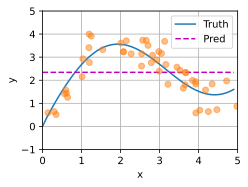

In [4]:
# 平均汇聚（Average Pooling / Average Aggregation），简单说就是：对一组数据取平均值，用这个平均值来代表整组数据
# y_train.mean():所有训练数据的标签（带噪声的点）求平均值
# torch.repeat_interleave (平均值，n_test):repeat_interleave：把一个数字重复n_test遍;结果：生成一个长度为 50 的张量，里面全是同一个平均值
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

## Nonparametric Attention Pooling

Obviously,average pooling ignores the input $x_i$.Thus,Nadaraya and Watson proposed a better idea: weighting the output $y_i$ based on the input's location:
$$
f(x)=\sum^{n}_{i=1}\frac{K(x-x_i)}{\sum^{n}_{j=1}K(x-x_j)}y_i
$$

Where,K is kernel.The estimator described by the equation above is known as Nadaraya-Watson Kernel Regression.
Inspired by this, the equation above can be rewritten from the perspective of the attention machanism framework to form a more general attention pooling formula:
$$
f(x)=\sum^{n}_{i=1}\alpha (x,x_i)y_i
$$

Where,x is query, $(x_i,y_i)$ represents the key-value pairs.
The attention pooling mechanism in the equation above is a weighted average of $y_i$
Model the relationship between the query $x$ and the keys $x_i$ as attention weights, which will be assigned to each corresponding value $y_i$.
For any query, the attention weights over all key-value pairs in the model constitute a valid probability distribution: they are non-negative and sum to 1.
To be better understand attention pooling, let's consider a Gaussion kernel,which is defined as:
$$
K(u)=\frac{1}{\sqrt{2\pi}}\exp(-\frac{u^2}{2})
$$

Substituting the Gaussian kernel into the equation above yields
$$
\begin{align*}
f(x)&=\sum^{n}_{i=1}\alpha (x,x_i)y_i\\
    &=\sum^{n}_{i=1}\frac{\exp(-\frac{1}{2}(x-x_i)^2)}{\sum^{n}_{j=1}\exp(-\frac{1}{2}(x-x_j)^2)}y_i\\
    &=\sum^{n}_{i=1}softmax(-\frac{1}{2}(x-x_i)^2)y_i
\end{align*}
$$

In the equation above, the closer a key $x_i$ is to a given query $x$, the larger the attention weight assigned to its corresponding value—meaning $y_i$ it "receives more attention."--获得了更多的注意力!
It is worth noting that the Nadaraya-Watson kernel regression is a non-parametric model. 
Therefore, the equation above represents a nonparametric attention pooling model.
Next, we will plot the prediction results based on this non-parametric attention pooling model. 
From the plotted results, we will find that the new model's prediction line is smooth and closer to the ground truth than the average pooling prediction.

非参数方法：无额外可学习参数，规则 / 函数形式固定，只依赖输入数据本身做计算，不靠训练更新权重。没有要训练的参数，逻辑写死。

参数方法：预先固定模型结构 + 可学习参数，训练中不断更新参数，拟合数据。有需要学的权重、矩阵、系数。

In [5]:
print(x_test)
print(x_train)

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000, 1.0000, 1.1000, 1.2000, 1.3000, 1.4000, 1.5000, 1.6000, 1.7000,
        1.8000, 1.9000, 2.0000, 2.1000, 2.2000, 2.3000, 2.4000, 2.5000, 2.6000,
        2.7000, 2.8000, 2.9000, 3.0000, 3.1000, 3.2000, 3.3000, 3.4000, 3.5000,
        3.6000, 3.7000, 3.8000, 3.9000, 4.0000, 4.1000, 4.2000, 4.3000, 4.4000,
        4.5000, 4.6000, 4.7000, 4.8000, 4.9000])
tensor([0.1388, 0.2972, 0.3480, 0.5610, 0.5975, 0.6126, 0.6425, 1.0112, 1.0335,
        1.1879, 1.1932, 1.1980, 1.2498, 1.5419, 2.0097, 2.0696, 2.0750, 2.1465,
        2.2711, 2.5375, 2.5404, 2.5663, 2.6589, 2.7027, 2.7886, 2.8193, 2.9289,
        2.9788, 2.9913, 3.0480, 3.1297, 3.1603, 3.2139, 3.4448, 3.5235, 3.6079,
        3.6540, 3.6588, 3.6759, 3.8432, 3.9234, 3.9274, 3.9291, 4.0292, 4.1772,
        4.2503, 4.3463, 4.4684, 4.7175, 4.9790])


In [6]:
# X_repeat的形状为(n_test,n_train)
# 每一行都包含相同的测试输入（例如同样的查询）
# 可以理解为有n_test行，n_train列
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
print(X_repeat)

tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
        [0.2000, 0.2000, 0.2000,  ..., 0.2000, 0.2000, 0.2000],
        ...,
        [4.7000, 4.7000, 4.7000,  ..., 4.7000, 4.7000, 4.7000],
        [4.8000, 4.8000, 4.8000,  ..., 4.8000, 4.8000, 4.8000],
        [4.9000, 4.9000, 4.9000,  ..., 4.9000, 4.9000, 4.9000]])


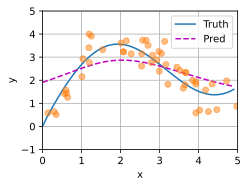

In [7]:
# x_train包含键。 attention_weights的形状为(n_test, n_train)
# 每一行都包含要在给定的每个查询的值(y_train)之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)  # 对应上面的公式
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

Now, let's observe the attention weights. 
Here, the input of the test data serves as the query, while the input of the training data acts as the key. 
Since both inputs are sorted, it can be observed that the closer a "query-key" pair is, the higher the attention weight in the attention pooling.

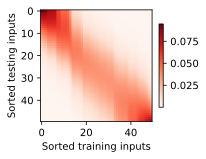

In [8]:
# d2l 的热力图函数 show_heatmaps 要求输入是 4D 张量：(批量大小 batch_size, 头数 num_heads, 行数, 列数)
# 第一个 unsqueeze(0) → 加 批量维度;第二个 unsqueeze(0) → 加 头数维度（单头注意力）
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                 xlabel='Sorted training inputs',
                 ylabel='Sorted testing inputs')

## Parametrized Attention Pooling

Nonparametric Nadaraya-Watson kernel regression enjoys the advantage of consistency:with sufficient data, the model converges to the optimal result.
Nevertheless, we can easily integrate learnable parameters into attention pooling.
For example,the following equation multiplies the distance between queries $x$ and keys $x_i$ by the learnable parameter $w$:
$$
\begin{align*}
f(x)&=\sum^{n}_{i=1}\alpha (x,x_i)y_i\\
    &=\sum^{n}_{i=1}\frac{\exp(-\frac{1}{2}((x-x_i)w)^2)}{\sum^{n}_{j=1}\exp(-\frac{1}{2}((x-x_j)w)^2)}y_i\\
    &=\sum^{n}_{i=1}softmax(-\frac{1}{2}((x-x_i)w)^2)y_i
\end{align*}
$$

To efficiently compute the attention for mini-batch data,we can leverage the batch matrix multiplication provided by deep learning franeworks.

Suppose the shape of two tensors are $(n,a,b)$ and $(n,b,c)$,respectively. The shape of the output from their batch matrix multiplication is $(n,a,c)$

In [9]:
# bmm = batch matrix multiplication（批量矩阵乘法），专门用于3 维张量的矩阵乘法，规则：
# 会将n批次的两矩阵相乘
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

Thereby calculating the weighted average within mini-batch data.


In [10]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
print(weights)
print(values)
# weights.unsqueeze(1)在第 1 维插入一维：原：[2, 10] 新形状：[2, 1, 10]
# values.unsqueeze(-1)在最后一维插入一维：原：[2, 10] 新形状：[2, 10, 1]
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000],
        [0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
         0.1000]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9.],
        [10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]])


tensor([[[ 4.5000]],

        [[14.5000]]])

In [11]:
# 定义模型

class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        # super().__init__()：固定写法，继承父类功能
        super().__init__(**kwargs)
        
        # 定义可学习参数 w：形状是 (1,)，也就是一个标量
        # 作用：控制“核函数的宽度”，模型会自动学习它,模型会自己学习这个参数，让预测更准
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))
        
    def forward(self, queries, keys, values):
        # 对Q做扩展
        # queries和attention_weights的形状为(查询个数，“键－值”对个数)
        # 让每个查询都能和所有键做减法:例子:查询：[x0];键：[x1, x2, x3];扩展后查询：[x0, x0, x0];这样才能算 x0-x1, x0-x2, x0-x3
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        
        # 计算注意力权重
        # attention = softmax(  - ((query - key) * w)²  /  2  )
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        
        # values的形状为(查询个数，“键－值”对个数)
        # 加权求和（注意力汇聚）
        # 做矩阵乘法：权重 × 值 = 加权平均
        # 加权平均 = 加权和/权重和 当权重和为1时 bmm结果就是加权平均
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)  # reshape(-1)  # 把结果展平成一维输出

Next, the training dataset is transformed into keys and values for training the attention model. 
In the parameterized attention pooling model, the input of each training sample is computed with the key-value pairs of all other training samples, so as to obtain its corresponding predicted output.


In [12]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))

# eye生成对角矩阵
# 假设eye(3) =
# [1,0,0]
# [0,1,0]
# [0,0,1]
# 1 所在位置 = 自己;0 所在位置 = 别人

# 1 - torch.eye剔除自己（留一法）
# 变成:
# [0,1,1]
# [1,0,1]
# [1,1,0]
# 0 = 自己（要剔除）1 = 别人（要保留）

# 结果：
# [x2, x3]  # 第1行：预测x1时，用别人x2、x3
# [x1, x3]  # 第2行：预测x2时，用别人x1、x3
# [x1, x2]  # 第3行：预测x3时，用别人x1、x2

# keys的形状:('n_train'，'n_train'-1) 即每一行剔除自己的值!
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

[训练带参数的注意力汇聚模型]时，使用平方损失函数和随机梯度下降。

平方损失函数:单个样本：$\ell(y,\hat{y})=\frac{1}{2}(y-\hat{y})^2$;$y$真实标签（标准答案）;$\hat{y}$模型预测值

批量整体损失：所有样本损失求平均:$L=\frac{1}{n}\sum^{n}_{i=1}\frac{1}{2}(y-\hat{y})^2$

正负误差统一变正数;误差越大，惩罚越重（误差翻倍放大）

随机梯度下降 SGD（Stochastic Gradient Descent）

每次只用 1 个样本 / 一小批样本 计算损失、算梯度、更新参数。
参数更新公式：$w=w-\eta \cdot \bigtriangledown L(w)$
w：模型可学习参数（权重、偏置、前面注意力里的 w）;\
η：学习率，控制每次更新步子大小;
$\bigtriangledown L(w)$:损失对参数的梯度（告诉参数：往哪边改，损失会变小）

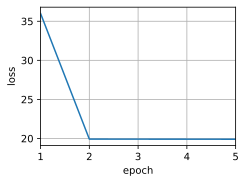

In [13]:
net = NWKernelRegression()
# 平方损失函数（均方损失、MSE 损失）
# reduction='none'返回：和输入形状一样的损失矩阵每个位置单独算损失，不合并、不求和、不平均。
# reduction='mean'（默认）返回：一个标量，所有损失的平均值最常用，用来反向传播更新模型。
loss = nn.MSELoss(reduction='none')
# net.parameters() = 模型里所有要训练的权重和偏置
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
# d2l画图工具
animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

for epoch in range(5):
    # 作用：清空上一轮的梯度！
    trainer.zero_grad()
    
    # net(...)：把数据喂给模型，得到预测值
    # loss(预测值, 真实值 y_train)：计算预测错了多少
    l = loss(net(x_train, keys, values), y_train)
    
    # .sum();把所有样本的损失加起来，变成一个总损失;因为 reduction='none' 不会自动求和 / 平均
    # .backward();(反向传播)对总损失求导,计算出每个参数需要调整多少（梯度）,梯度存在参数里，等待优化器更新
    l.sum().backward()
    
    # 优化器根据梯度，更新权重和偏置！
    # trainer = SGD 优化器;它拿着刚才算出的梯度;自动调整 net 里的所有参数;让模型下一次预测更准
    trainer.step()
    
    # 打印总损失（越小说明模型预测越准）
    print(f'epoch {epoch + 1}, loss {float(l.sum()):.6f}')
    
    # 画图（动态显示损失曲线）
    animator.add(epoch + 1, float(l.sum()))

As shown below, after training the parameterized attention pooling model, it can be observed that when attempting to fit noisy training data, the curve plotted from the prediction results is less smooth than that of the previous non-parametric model.

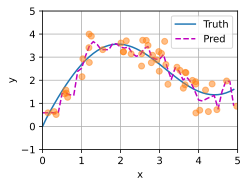

In [14]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）(key--x)
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)(value--y)
values = y_train.repeat((n_test, 1))

# 训练好的 net 已经学会了最优的注意力宽度 w;现在要给它新的测试点 x_test，让它预测输出
# x_test：要预测的查询点（比如要预测的 x 坐标）
# keys：全部训练键（每个测试点都能看到所有训练 x）
# values：全部训练值（每个测试点都能看到所有训练 y）
y_hat = net(x_test, keys, values).unsqueeze(1).detach()

# 作图
plot_kernel_reg(y_hat)

Why does the new model produce less smooth results? Let us examine the plot of the output results. Compared with the non-parametric attention pooling model, the parameterized model introduces learnable parameters, causing the curve to become less smooth in regions with larger attention weights.

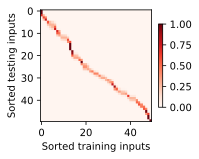

In [15]:
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

## 小结

* Nadaraya-Watson核回归是具有注意力机制的机器学习范例。
* Nadaraya-Watson核回归的注意力汇聚是对训练数据中输出的加权平均。从注意力的角度来看，分配给每个值的注意力权重取决于将值所对应的键和查询作为输入的函数。
* 注意力汇聚可以分为非参数型和带参数型。

## 练习

1. 增加训练数据的样本数量，能否得到更好的非参数的Nadaraya-Watson核回归模型？
1. 在带参数的注意力汇聚的实验中学习得到的参数$w$的价值是什么？为什么在可视化注意力权重时，它会使加权区域更加尖锐？
1. 如何将超参数添加到非参数的Nadaraya-Watson核回归中以实现更好地预测结果？
1. 为本节的核回归设计一个新的带参数的注意力汇聚模型。训练这个新模型并可视化其注意力权重。